{'topic': '猫咪', 'poem': AIMessage(content='## 《夜巡者》\n\n它们沿墙根标注温柔的边界\n或停在路灯下侧耳\n听远处炊烟是否飘来\n瓷碗轻敲的节奏\n\n两只毛茸茸的巡逻兵\n用爪垫校准夜的深度\n它们藏起闪电与利钩\n在窗台排列成\n散发着腥气的月轮\n\n我的脚踝曾被绒毛缠绕\n像困于蜜糖的昆虫\n当尾巴竖起问询的弧度\n我总在晨光泄露前坦白\n毕竟连信纸都学会\n用呢喃代替尖刺', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 116, 'prompt_tokens': 10, 'total_tokens': 126, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 10}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': 'ec11afb3-febb-4183-a235-db1c6d039d08', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fa259-b103-7153-aec4-ec1992a2c14e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10, 'output_tokens': 116, 'total_tokens': 126, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}}), 'ci_poe

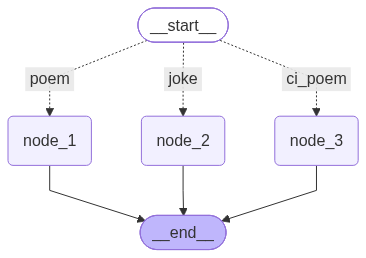

In [1]:
# -*- coding: utf-8 -*-
# 【CP2-04 多路条件】返回 Sequence 实现“一次触发多节点”的条件扇出
# 文件：CP2/04_route2.ipynb
# 作用：本 Cell 演示 【CP2-04 多路条件】返回 Sequence 实现“一次触发多节点”的条件扇出 的完整可运行示例
# 阅读顺序：状态定义 → 节点定义 → 图构建 → 编译执行 → 结果观察

from dotenv import load_dotenv
from typing import TypedDict
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph,START,END    
from typing import TypedDict, Annotated,Literal,Sequence
load_dotenv()

model = ChatDeepSeek(
    model = "deepseek-v4-flash",
    extra_body={        
        "thinking":{
            "type":"disabled"
        }
    }
)

# 1 定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    ci_poem: str
    content_type: str

def node_1(state : OverAllState) -> OverAllState:
    # 向全局状态添加poem
    return {
        "poem": model.invoke(f"请写一首关于{state['topic']}的诗"),  # AND 汇合：需全部前驱完成才触发下游
    }

def node_2(state : OverAllState) -> OverAllState:
    # 向全局状态添加joke
    return {
        "joke": model.invoke(f"请写一个关于{state['topic']}的笑话"),  # AND 汇合：需全部前驱完成才触发下游
    }

def node_3(state : OverAllState) -> OverAllState:
    # 向全局状态添加ci_poem
    return {
        "ci_poem": model.invoke(f"请写一首关于{state['topic']}的词"),  # AND 汇合：需全部前驱完成才触发下游
    }

# 添加路由
def my_route(state : OverAllState) -> Sequence[Literal["poem", "joke", "ci_poem"]]:
    # 根据topic判断是否需要路由
    if "诗" in state["content_type"]:
        return ["poem","ci_poem"]
    else:
        return ["joke","ci_poem"]

# 2 构建状态图
builder = StateGraph(state_schema=OverAllState)  # 创建状态图构建器：绑定状态 Schema
builder.add_node("node_1", node_1)  # 注册节点到图中
builder.add_node("node_2", node_2)  # 注册节点到图中
builder.add_node("node_3", node_3)  # 注册节点到图中

builder.add_conditional_edges(  # 条件边 + path_map：路由键与节点名解耦
    START,my_route,path_map={
        "poem":"node_1",
        "joke":"node_2",
        "ci_poem":"node_3"
        }
    )
    
builder.add_edge("node_1", END)  # 汇入终点
builder.add_edge("node_2", END)  # 汇入终点
builder.add_edge("node_3", END)  # 汇入终点

graph = builder.compile()  # 编译图：蓝图→可执行对象

result1 = graph.invoke({"topic": "猫咪","content_type":"诗"})  # 触发图执行：传入初始 State + config
print(result1)

result2 = graph.invoke({"topic": "猫咪","content_type":"笑话"})  # 触发图执行：传入初始 State + config
print(result2)


from IPython.display import display
display(graph)
